In [1]:
!pip install datasets pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 3.5 MB/s  0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.4.0
    Uninstalling fsspec-2026.4.0:
      Successfully uninstalled fsspec-2026.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [datasets]/12 [datasets]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

In [3]:
# Load IMDb dataset from HuggingFace
imdb = load_dataset("imdb")

print(imdb)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
# convert to pandas frame
train_df = pd.DataFrame(imdb['train'])
test_df = pd.DataFrame(imdb['test'])

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (25000, 2)
Test Shape: (25000, 2)


In [5]:
# display first row
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [6]:
# show example review
print("Example Review:\n")
print(train_df['text'][0])

print("\nLabel:", train_df['label'][0])


Example Review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

In [7]:
#check missin values
print(train_df.isnull().sum())

text     0
label    0
dtype: int64


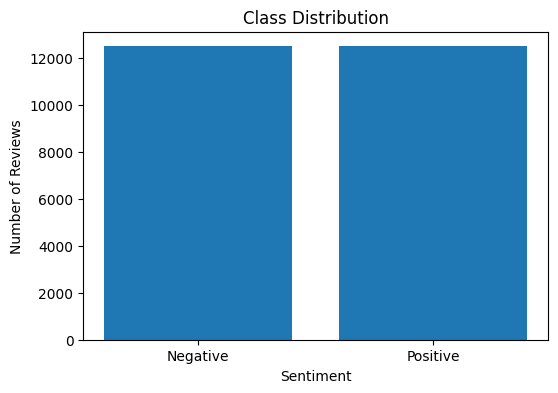

In [8]:
# class distribution 
label_counts = train_df['label'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(label_counts.index, label_counts.values)

plt.xticks([0,1], ['Negative', 'Positive'])

plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.title('Class Distribution')

plt.show()

In [9]:
# text length
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))

train_df[['text_length']].head()

,text_length
0,288
1,214
2,93
3,118
4,311


In [10]:
# average review length
average_length = train_df['text_length'].mean()

print("Average Review Length:", average_length)

Average Review Length: 233.7872


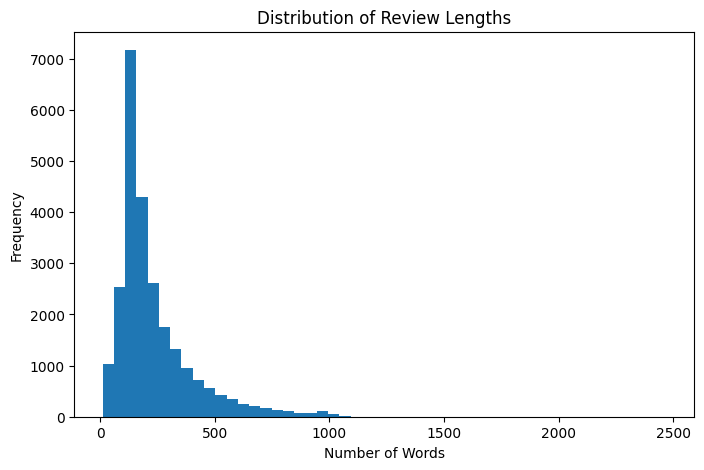

In [11]:
# histogram of review lenght
plt.figure(figsize=(8,5))

plt.hist(train_df['text_length'], bins=50)

plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')

plt.show()

In [13]:
## Observations
- The dataset contains 50,000 movie reviews.
- The classes are balanced between positive and negative reviews.
- Some reviews are very long.
- The average review length is around 230 words.
- Long reviews may affect RNN performance.
- Transformer models can better capture long-range dependencies.

SyntaxError: invalid syntax (3458750481.py, line 2)

In [14]:
# save csv files
train_df.to_csv("imdb_train.csv", index=False)
test_df.to_csv("imdb_test.csv", index=False)